# Evaluation

In [1]:
import numpy as np
import torch
from src.models.model_0 import TabularModel
from pytorch_lightning import Trainer
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
model_path = "../output/models/checkpoints/"
model_name = "model-epoch=23-val_loss=0.3208-v2.ckpt"

batch_size = 32

In [3]:
model_path += model_name

## Load data

In [4]:
X_test  = np.load('../data/processed/X_test.npy')
input_dim = X_test.shape[1]

y_test  = np.load('../data/processed/y_test.npy')

In [5]:
X_test_tensor  = torch.from_numpy(X_test.astype(np.float32))

y_test_tensor  = torch.from_numpy(y_test.astype(np.float32))

In [6]:
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

test_loader  = DataLoader(test_dataset, batch_size=batch_size)

## Load model

In [7]:
model = TabularModel.load_from_checkpoint(model_path, input_dim=input_dim)

## Test

In [8]:
trainer = Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Accuracy

In [9]:
trainer.test(model, dataloaders=test_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 3070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\danilo\DataspellProjects\pytorch-tutorial2\venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8633333444595337
        test_loss           0.33290210366249084
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.33290210366249084, 'test_acc': 0.8633333444595337}]

## Confusion matrix

In [10]:
preds = trainer.predict(model, dataloaders=test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\danilo\DataspellProjects\pytorch-tutorial2\venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:424: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [11]:
logits = torch.cat(preds)
probs = torch.sigmoid(logits)
y_pred = np.array((probs > 0.5).int())

In [12]:
cm = confusion_matrix(y_test, y_pred)

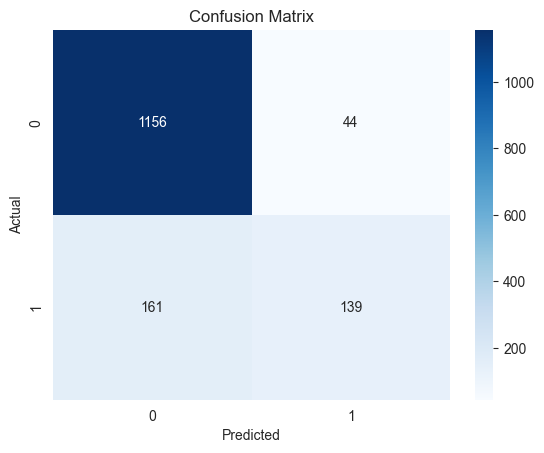

In [13]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification report

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1200
           1       0.76      0.46      0.58       300

    accuracy                           0.86      1500
   macro avg       0.82      0.71      0.75      1500
weighted avg       0.85      0.86      0.85      1500

